In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
results = pd.read_csv(
    r"E:\Hybrid_IDS_Project\dataset\results\unknown_attack_results.csv"
)

results

,Model,Experiment,Accuracy,Precision,Recall,F1_Score,FPR,TN,FP,FN,TP
0,Random Forest,Unknown Attack Test,0.573203,0.996222,0.146963,0.256140,0.000557,12554,7,10715,1846
1,MLP,Unknown Attack Test,0.556285,0.997187,0.112889,0.202818,0.000318,12557,4,11143,1418
2,CNN,Unknown Attack Test,0.575591,0.903527,0.169254,0.285101,0.018072,12334,227,10435,2126
3,OCSVM,Unknown Attack Test,0.796394,0.927833,0.642783,0.759441,0.049996,11933,628,4487,8074
4,LOF,Unknown Attack Test,0.552185,0.752991,0.155322,0.257524,0.050951,11921,640,10610,1951


In [12]:
import os

output_folder = r"E:\Hybrid_IDS_Project\dataset\results"

os.makedirs(output_folder, exist_ok=True)

print("Output folder ready!")

Output folder ready!


Accuracy Comparison

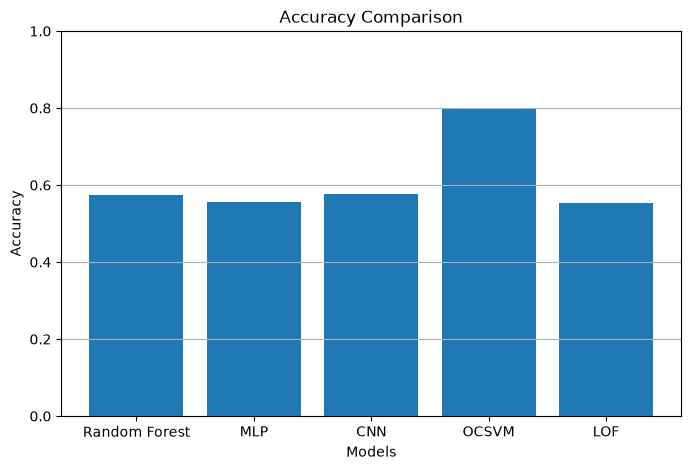

In [13]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.ylim(0,1)
plt.grid(axis='y')

plt.savefig(
    rf"{output_folder}\accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Precision Comparison

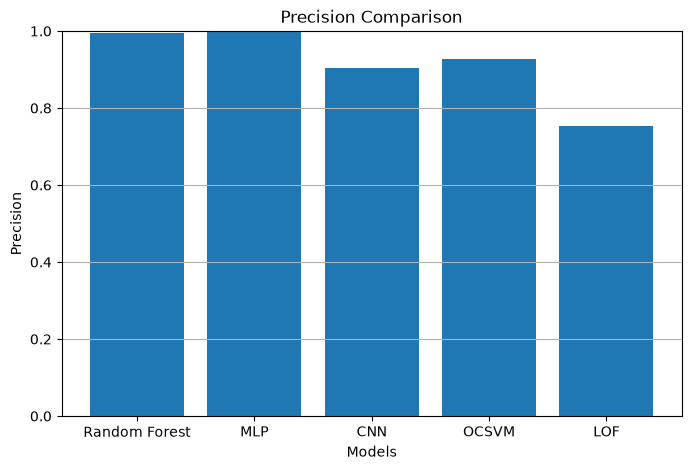

In [14]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Precision"])

plt.title("Precision Comparison")
plt.xlabel("Models")
plt.ylabel("Precision")

plt.ylim(0,1)
plt.grid(axis='y')

plt.savefig(
    rf"{output_folder}\precision_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Recall Comparison

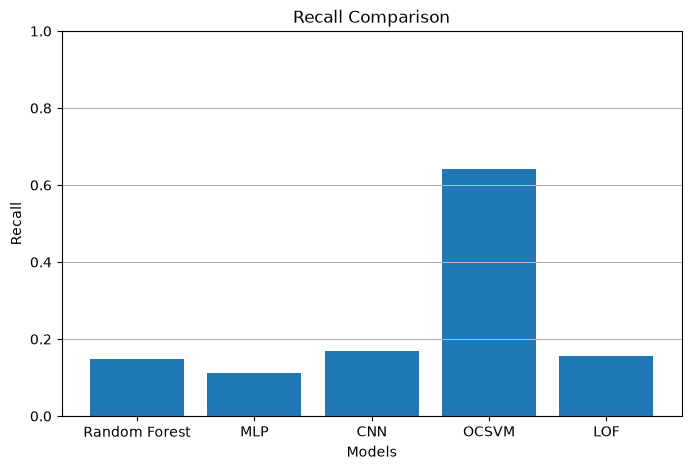

In [15]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Recall"])

plt.title("Recall Comparison")
plt.xlabel("Models")
plt.ylabel("Recall")

plt.ylim(0,1)
plt.grid(axis='y')

plt.savefig(
    rf"{output_folder}\recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

F1-Score Comparison

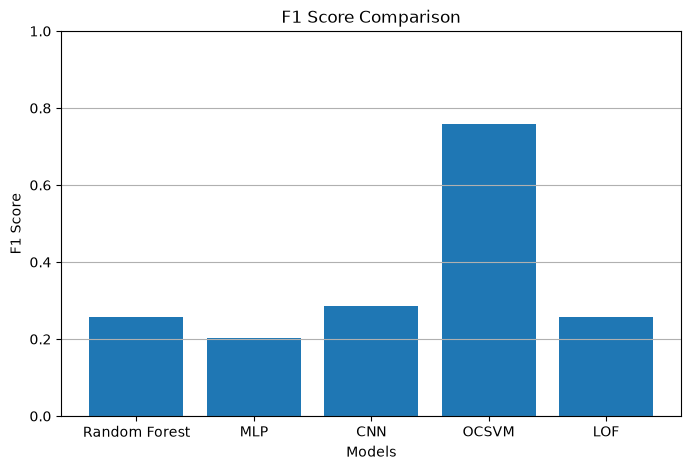

In [16]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["F1_Score"])

plt.title("F1 Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.ylim(0,1)
plt.grid(axis='y')

plt.savefig(
    rf"{output_folder}\f1score_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

 False Positive Rate Comparison

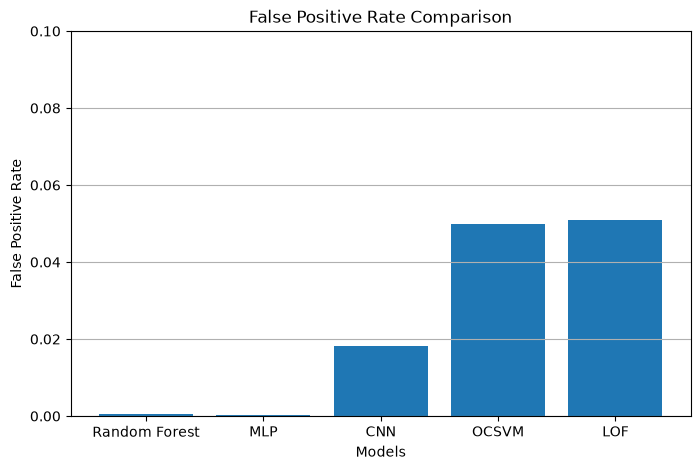

In [17]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["FPR"])

plt.title("False Positive Rate Comparison")
plt.xlabel("Models")
plt.ylabel("False Positive Rate")

plt.ylim(0,0.1)
plt.grid(axis='y')

plt.savefig(
    rf"{output_folder}\fpr_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Generate All Graphs Automatically

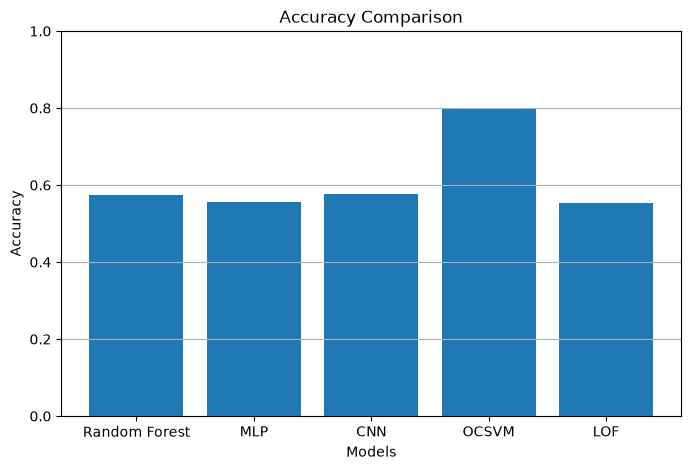

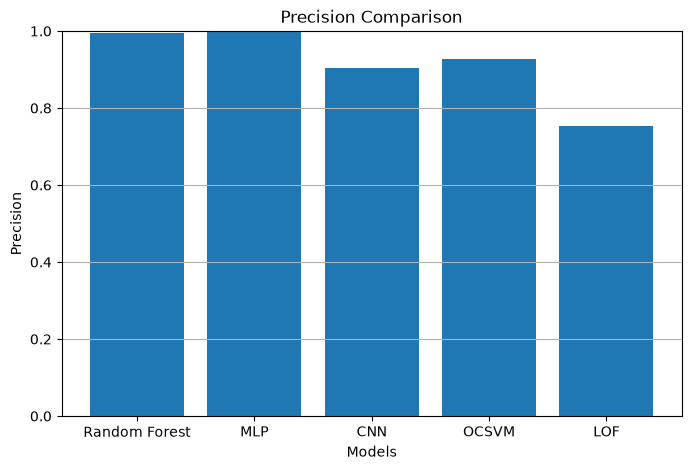

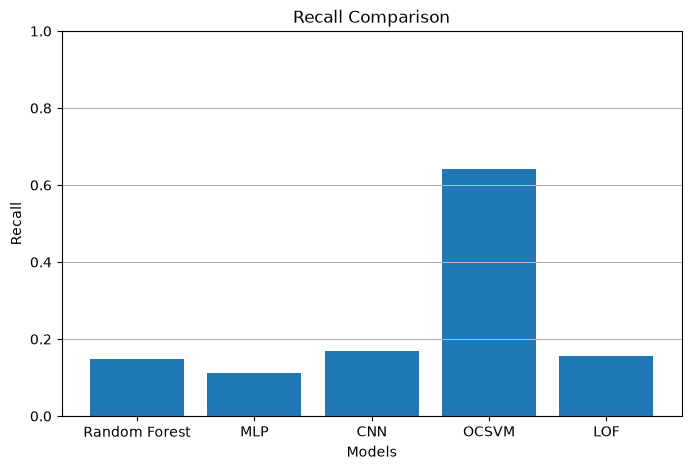

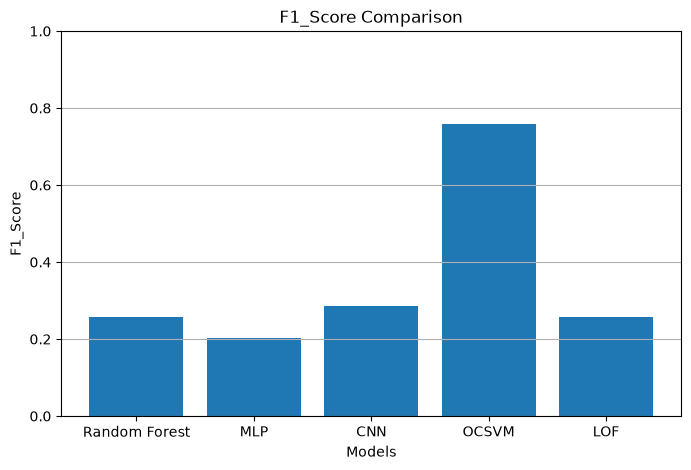

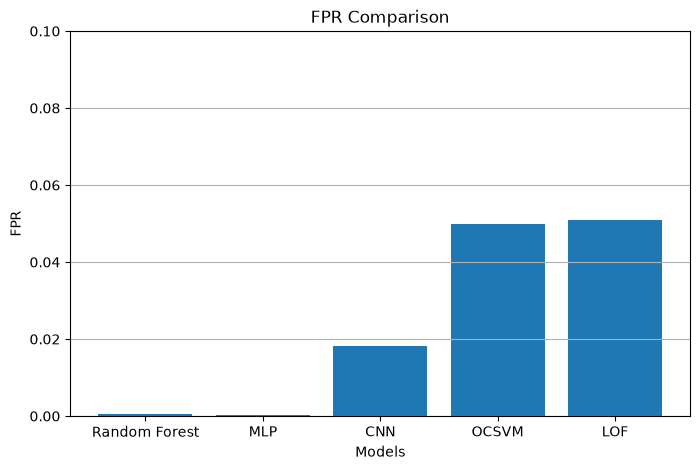

In [18]:
metrics = {
    "Accuracy": "accuracy_comparison.png",
    "Precision": "precision_comparison.png",
    "Recall": "recall_comparison.png",
    "F1_Score": "f1score_comparison.png",
    "FPR": "fpr_comparison.png"
}

for metric, filename in metrics.items():

    plt.figure(figsize=(8,5))

    plt.bar(results["Model"], results[metric])

    plt.title(f"{metric} Comparison")

    plt.xlabel("Models")
    plt.ylabel(metric)

    if metric != "FPR":
        plt.ylim(0,1)
    else:
        plt.ylim(0,0.1)

    plt.grid(axis="y")

    plt.savefig(
        rf"{output_folder}\{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

Confusion Matrix Visualization

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Load Results

In [20]:
results = pd.read_csv(
    r"E:\Hybrid_IDS_Project\dataset\results\unknown_attack_results.csv"
)

results

,Model,Experiment,Accuracy,Precision,Recall,F1_Score,FPR,TN,FP,FN,TP
0,Random Forest,Unknown Attack Test,0.573203,0.996222,0.146963,0.256140,0.000557,12554,7,10715,1846
1,MLP,Unknown Attack Test,0.556285,0.997187,0.112889,0.202818,0.000318,12557,4,11143,1418
2,CNN,Unknown Attack Test,0.575591,0.903527,0.169254,0.285101,0.018072,12334,227,10435,2126
3,OCSVM,Unknown Attack Test,0.796394,0.927833,0.642783,0.759441,0.049996,11933,628,4487,8074
4,LOF,Unknown Attack Test,0.552185,0.752991,0.155322,0.257524,0.050951,11921,640,10610,1951


Create Output Folder

In [21]:
import os

output_folder = r"E:\Hybrid_IDS_Project\dataset\results\confusion_matrices"

os.makedirs(output_folder, exist_ok=True)

Generate Confusion Matrix for All Models

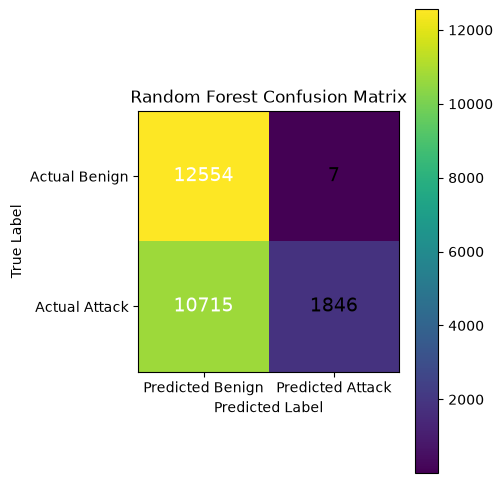

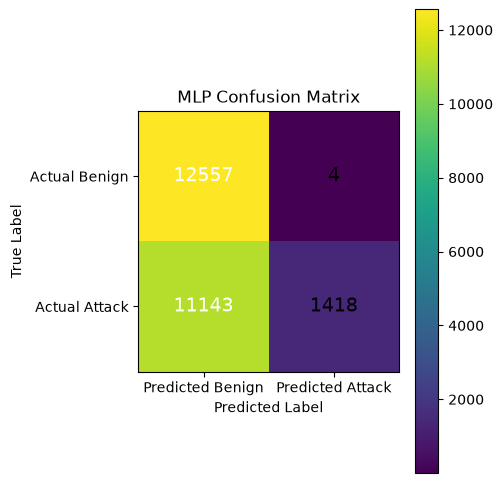

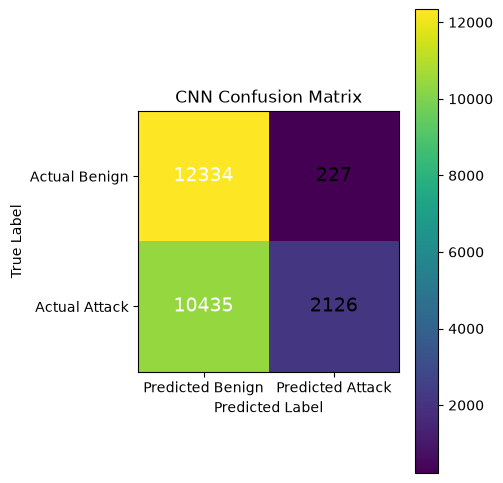

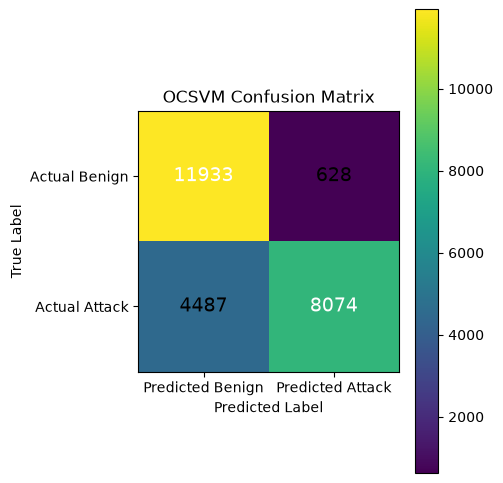

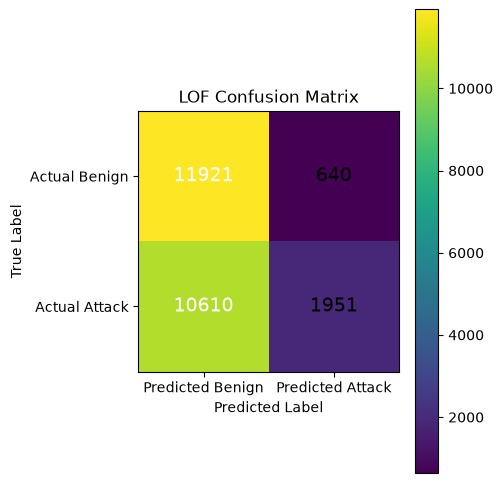

In [22]:
for _, row in results.iterrows():

    model = row["Model"]

    tn = int(row["TN"])
    fp = int(row["FP"])
    fn = int(row["FN"])
    tp = int(row["TP"])

    cm = np.array([
        [tn, fp],
        [fn, tp]
    ])

    plt.figure(figsize=(5,5))

    plt.imshow(cm)

    plt.title(f"{model} Confusion Matrix")

    plt.xticks([0,1], ["Predicted Benign", "Predicted Attack"])
    plt.yticks([0,1], ["Actual Benign", "Actual Attack"])

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    # Write numbers inside boxes
    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                str(cm[i,j]),
                ha="center",
                va="center",
                fontsize=14,
                color="white" if cm[i,j] > cm.max()/2 else "black"
            )

    plt.colorbar()

    plt.tight_layout()

    plt.savefig(
        rf"{output_folder}\{model}_confusion_matrix.png",
        dpi=300
    )

    plt.show()

In [23]:
import os

for root, dirs, files in os.walk(r"E:\Hybrid_IDS_Project"):
    for file in files:
        if "scaler" in file.lower():
            print(os.path.join(root, file))

E:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\tensorflow\include\external\libwebp\src\utils\rescaler_utils.h
E:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\torch\amp\grad_scaler.py
E:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\torch\amp\__pycache__\grad_scaler.cpython-311.pyc
E:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\torch\cpu\amp\grad_scaler.py
E:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\torch\cpu\amp\__pycache__\grad_scaler.cpython-311.pyc
E:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\torch\cuda\amp\grad_scaler.py
E:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\torch\cuda\amp\__pycache__\grad_scaler.cpython-311.pyc
E:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\torch\distributed\fsdp\sharded_grad_scaler.py
E:\Hybrid_IDS_Project\dataset\venv\Lib\site-packages\torch\distributed\fsdp\__pycache__\sharded_grad_scaler.cpython-311.pyc
